# **Método del Descenso del Gradiente**
El descenso de Gradiente es un método comúnmente utilizado en problemas de optimización. Es como intentar encontrar el punto más bajo en un paisaje montañoso. Se comienza en un punto al azar y se dan pasos pequeños en direccion contraria al gradiente, que es la dirección del descenso más empinado. La función objetivo se minimiza mediante el cálculo del siguiente punto, utilizando el gradiente del punto actual, escalando con una razón de aprendizaje. La convergencia del algoritmo depende de la elección de la tasa de aprendizaje y el número de iteraciones.

El procedimiento funciona de la siguienta manera se elige un punto (X0,Y0) y una tasa de aprendizaje α. Se calcula el gradiente y a medida se van actualizando las variables de la siguiente forma:
$$
\begin{aligned}
x_{k+1} &= x_k - \alpha \frac{\partial f}{\partial x}(x_k, y_k), \\
y_{k+1} &= y_k - \alpha \frac{\partial f}{\partial y}(x_k, y_k)
\end{aligned}
$$

El método continua la iteración hasta llegar a algún criterio de parada:
- $\|\nabla f(x_k, y_k)\| < \text{tolerancia}$
- Número máximo de iteraciones
- Cambio pequeño en $f(x, y)$ entre iteraciones

El método del gradiente descendiente con backtracking cambia el α en cada iteración no es fijo, entonces así se actualizarían las variables:
$$
\begin{aligned}
x_{k+1} = x_k - \alpha_k \nabla f(x_k)
\end{aligned}
$$ 

El α se ajusta para cumplir la condición de Armijo:
$$
\begin{aligned}
f\big(x_k - \alpha_k \nabla f(x_k)\big) \le f(x_k) - c \, \alpha_k \, \|\nabla f(x_k)\|^2
\end{aligned}
$$
Si la condición no se cumple se reduce αk mutplicando por ρ.
En el método del GD sin backtracking no existe control, ya que el paso no depende de la función, es fijo. Si α es muy grande el método puede divergir y si es muy pequeño el método tendría una convergencia lenta. Sin embargo el método sin backtracking es bastante fácil implementar.
Por otro lado, en la implementación con backtracking el paso es variable, adaptándose a la función por lo que existe un mayor control. Se asegura que cada iteración reduzca suficiente la función. El método con el uso de backtracking es más estable, puede converger incluso en funciones con valles estrechos o pendientes muy pronunciadas. Pero como cada iteración requiere evaluar la función varias veces, es más costoso.

En la función correspondiente:
$$
\begin{aligned}
f(x, y) = \sin(x+y) + \frac{(x+y)^2 + (x-y)^2}{6}
\end{aligned}
$$
La función es derivable lo cual es ideal para GD que requiere el uso del gardiente.

La parte cuadrática:
$$
\begin{aligned}
\frac{(x+y)^2 + (x-y)^2}{6}
\end{aligned}
$$
- Es convexa, suave y bien condicionada.  
- Tiene una forma de “valle parabólico”.  
- Para esta parte, el gradiente descendente converge rápido incluso con paso fijo.
La parte del seno:
$$
\begin{aligned}
\sin(x+y)
\end{aligned}
$$
- Introduce oscilaciones y posibles mínimos locales.  
- GD puede explorar la función gradualmente y descender hacia un mínimo local.

### Sin backtracking

- La función es suave y no tiene cambios extremos de curvatura, por lo que un paso razonable puede funcionar.  
- Es rápido de implementar, útil para probar mínimos locales.

### Con backtracking

- La parte sinusoidal puede producir zonas donde el gradiente es grande o muy pequeño.  
- Backtracking ajusta el paso automáticamente, evitando sobrepasar mínimos y mejorando la estabilidad.  
- Es especialmente útil para explorar zonas más alejadas del mínimo, donde el gradiente puede cambiar rápidamente.

# Método de Newton para optimización

El método de Newton es un algoritmo iterativo para encontrar mínimos (o máximos) de funciones diferenciables usando información de primera y segunda derivada. A diferencia del gradiente descendente, Newton utiliza la matriz Hessiana para determinar la dirección y el tamaño del paso óptimo.

Para una función \(f(x, y)\):

 Gradiente

$$
\nabla f(x, y) =
\begin{pmatrix}
\frac{\partial f}{\partial x} \\
\frac{\partial f}{\partial y}
\end{pmatrix}
$$

 Hessiana

$$
H(x, y) =
\begin{pmatrix}
\frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\
\frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2}
\end{pmatrix}
$$

 Aproximación cuadrática

$$
f(x + \Delta x, y + \Delta y) \approx f(x, y) + \nabla f^T \Delta + \frac{1}{2} \Delta^T H \Delta
$$

donde

$$
\Delta =
\begin{pmatrix} \Delta x \\ \Delta y \end{pmatrix}
$$

 Actualización clásica

$$
H(x_k, y_k) \, \Delta_k = \nabla f(x_k, y_k)
$$

$$
(x_{k+1}, y_{k+1}) = (x_k, y_k) - \Delta_k = (x_k, y_k) - H(x_k, y_k)^{-1} \nabla f(x_k, y_k)
$$

## Damping (amortiguación) en el método de Newton

Newton puro puede divergir si:

- La Hessiana no es positiva definida.  
- Estamos lejos del mínimo.  
- La función presenta oscilaciones, como en \(\sin(x+y)\).

Para mejorar la estabilidad, se introducen dos mecanismos de damping:

 Factor de escala αk (line search)

Se multiplica la dirección de Newton por un factor αk que pertenece al intervalo (0,1] que se ajusta mediante backtracking:

$$
(x_{k+1}, y_{k+1}) = (x_k, y_k) - \alpha_k \, H(x_k, y_k)^{-1} \, \nabla f(x_k, y_k)
$$

- Cerca del mínimo, αk ≈ 1 y el método conserva su convergencia cuadrática.  
- Si la dirección de Newton es riesgosa, \(\alpha_k < 1\) reduce el paso y evita divergencia.

 Regularización de la Hessiana (Levenberg–Marquardt)

Se añade un término λI a la Hessiana para garantizar que sea positiva definida:

$$
(H(x_k, y_k) + \lambda \, I) \, \Delta_k = \nabla f(x_k, y_k)
$$

- λ > 0 regula la amortiguación:  
  - Valores grandes → comportamiento similar al gradiente descendente (pasos pequeños y seguros).  
  - Valores pequeños → comportamiento cercano a Newton puro.  
- \(I\) es la matriz identidad de tamaño igual a la Hessiana.  

 Ventajas del damping

- Garantiza descenso seguro de la función en cada iteración.  
- Permite que Newton sea robusto frente a oscilaciones o puntos de silla.  
- Combina la rapidez de Newton cerca del mínimo con la estabilidad del gradiente descendente en regiones difíciles.

El método de Newton presenta varias ventajas para la función correspondiente. Primero, tiene convergencia rápida en la parte cuadrática, ya que la porción parabólica de la función se aprovecha al máximo, permitiendo que Newton alcance el mínimo local en pocas iteraciones. Además, ofrece un manejo eficiente de la curvatura variable: la parte sinusoidal introduce cambios en la curvatura según la posición, y Newton ajusta la dirección y el tamaño del paso basándose en la Hessiana, tomando decisiones más informadas que el gradiente descendente. Por último, el damping garantiza estabilidad, ya que en zonas alejadas del mínimo o con oscilaciones fuertes, evita que Newton haga saltos excesivos y diverja. Esto hace que el método sea robusto incluso al explorar regiones complicadas de la función.

In [10]:
#Experimentos a llevar a cabo
EXPERIMENTS = [
    {
        "name": "gd_lr_0.1_init_0",
        "method": "gd",  # método de gradiente descendente
        "init": [0.0, 0.0], #punto inicial
        "lr": 0.1,  #paso
        "tol": 1e-6,  #tolerancia para el criterio de parada
        "max_iter": 5000,  #iteraciones máximas
        "use_backtracking": False
    },
    {
        "name": "gd_lr_0.01_init_2_backtracking",
        "method": "gd",
        "init": [2.0, -1.0],
        "lr": 0.01,
        "tol": 1e-6,
        "max_iter": 10000,
        "use_backtracking": True,  # uso de búsqueda lineal por backtracking
        "bt_rho": 0.5,  #factor de reducción del paso en backtracking 
        "bt_c": 1e-4    #constante para la condición de Armijo
    },
    {
        "name": "gd_lr_0.2_init_-2_backtracking",
        "method": "gd",
        "init": [-2.0, 2.0],
        "lr": 0.2,
        "tol": 1e-6,
        "max_iter": 5000,
        "use_backtracking": True,
        "bt_rho": 0.5,
        "bt_c": 1e-4
    },
    {
        "name": "newton_damped_init_0",
        "method": "newton",
        "init": [0.0, 0.0],
        "tol": 1e-9,
        "max_iter": 200,
        "damping": 1e-6,  #regulación de la hessiana
        "line_search": True  # uso de búsqueda lineal
    },
    {
        "name": "newton_far_init_3",
        "method": "newton",
        "init": [3.0, 3.0],
        "tol": 1e-9,
        "max_iter": 500,
        "damping": 1e-4,
        "line_search": True
    }
    
]


In [11]:
#Son definidas las funciones del método del gradiente descendiente y del método de Newton
import numpy as np

# ----- Función, gradiente y Hessiana -----
def f(xy):
    x, y = float(xy[0]), float(xy[1])
    return np.sin(x + y) + ((x + y)**2 + (x - y)**2) / 6

def grad(xy):
    x, y = xy[0], xy[1]
    df_dx = np.cos(x + y) + (2 * x) / 3
    df_dy = np.cos(x + y) + (2 * y) / 3
    return np.array([df_dx, df_dy])

def hessian(xy):
    x, y = xy[0], xy[1]
    s = np.sin(x + y)
    return [
        [-s + 2/3, -s],
        [-s, -s + 2/3]
    ]

# ----- Algoritmo: Backtracking Armijo (opcional) -----
def backtracking_line_search(xk, pk, fk, gk, rho=0.5, c=1e-4, max_steps=40):
    alpha = 1.0
    for _ in range(max_steps):
        x_new = xk + alpha * pk
        f_new = f(x_new)
        if f_new <= fk + c * alpha * np.dot(gk, pk):
            return alpha
        alpha *= rho
    return alpha

# ----- Descenso por Gradiente -----
def gradient_descent(x0, lr=0.01, tol=1e-6, max_iter=10000, use_backtracking=False, bt_params=None):
    x = np.array(x0, dtype=float)
    history = {"xs": [], "fs": [], "grads": []}
    for k in range(max_iter):
        g = grad(x)
        normg = np.linalg.norm(g)
        fx = f(x)
        history["xs"].append(x.copy())
        history["fs"].append(fx)
        history["grads"].append(normg)
        if normg < tol:
            break
        pk = -g
        if use_backtracking:
            rho = bt_params.get("bt_rho", 0.5)
            c = bt_params.get("bt_c", 1e-4)
            alpha = backtracking_line_search(x, pk, fx, g, rho=rho, c=c)
        else:
            alpha = lr
        x = x + alpha * pk
    return {"x": x, "f": f(x), "grad_norm": np.linalg.norm(grad(x)), "iters": k+1, "history": history}

# ----- Método de Newton (regularizado / damping) -----
def newton_method(x0, tol=1e-9, max_iter=200, damping=1e-6, line_search=True):
    x = np.array(x0, dtype=float)
    history = {"xs": [], "fs": [], "grad_norm": []}
    for k in range(max_iter):
        g = grad(x)
        H = hessian(x)
        fk = f(x)
        history["xs"].append(x.copy())
        history["fs"].append(fk)
        history["grad_norm"].append(np.linalg.norm(g))
        if np.linalg.norm(g) < tol:
            break
        H_reg = H + damping * np.eye(2)
        try:
            pk = -np.linalg.solve(H_reg, g)
        except np.linalg.LinAlgError:
            pk = -g
        alpha = 1.0
        if line_search:
            alpha = backtracking_line_search(x, pk, fk, g, rho=0.5, c=1e-4)
        x = x + alpha * pk
    return {"x": x, "f": f(x), "grad_norm": np.linalg.norm(grad(x)), "iters": k+1, "history": history}


In [12]:

#Almacenamiento de los experimentos en un json
import json
import numpy as np

def run_experiment(cfg):
    method = cfg["method"]
    x0 = cfg["init"]
    result = None
    if method == "gd":
        bt_params = {}
        if cfg.get("use_backtracking"):
            bt_params = {"bt_rho": cfg.get("bt_rho", 0.5), "bt_c": cfg.get("bt_c", 1e-4)}
        result = gradient_descent(x0, lr=cfg.get("lr", 0.01), tol=cfg.get("tol",1e-6),
                                  max_iter=cfg.get("max_iter",5000),
                                  use_backtracking=cfg.get("use_backtracking", False),
                                  bt_params=bt_params)
    elif method == "newton":
        result = newton_method(x0, tol=cfg.get("tol",1e-9), max_iter=cfg.get("max_iter",200),
                               damping=cfg.get("damping",1e-6), line_search=cfg.get("line_search", True))
    else:
        raise ValueError("Unknown method "+str(method))
    # structure result for JSON serializable
    hist = result["history"]
    hist_serial = {
        "xs": [[float(a), float(b)] for a,b in hist["xs"]],
        "fs": [float(v) for v in hist["fs"]],
    }
    if "grads" in hist:
        hist_serial["grads"] = [float(g) for g in hist["grads"]]
    elif "grad_norm" in hist:
        hist_serial["grad_norm"] = [float(g) for g in hist["grad_norm"]]
    out = {
        "config": cfg,
        "result": {
            "x": [float(result["x"][0]), float(result["x"][1])],
            "f": float(result["f"]),
            "grad_norm": float(result["grad_norm"]),
            "iters": int(result["iters"])
        },
        "history": hist_serial
    }
    return out

def run_all_and_save(filename="experiments_results.json"):
    all_results = []
    for cfg in EXPERIMENTS:
        print("Running:", cfg["name"])
        res = run_experiment(cfg)
        all_results.append(res)
    with open(filename, "w") as fp:
        json.dump(all_results, fp, indent=2)
    print("Saved results to", filename)
    return filename

if __name__ == "__main__":
    run_all_and_save("experiments_results.json")


Running: gd_lr_0.1_init_0
Running: gd_lr_0.01_init_2_backtracking
Running: gd_lr_0.2_init_-2_backtracking
Running: newton_damped_init_0
Running: newton_far_init_3
Saved results to experiments_results.json


=== Summary Table ===
                          name method        init   final_x   final_y   f_final    grad_norm  iters
              gd_lr_0.1_init_0     gd  (0.0, 0.0) -0.585060 -0.585060 -0.692601 9.497049e-07     53
gd_lr_0.01_init_2_backtracking     gd (2.0, -1.0) -0.585060 -0.585061 -0.692601 4.871536e-07     23
gd_lr_0.2_init_-2_backtracking     gd (-2.0, 2.0) -0.585061 -0.585060 -0.692601 9.814262e-07     23
          newton_damped_init_0 newton  (0.0, 0.0) -0.585060 -0.585060 -0.692601 2.452029e-11      5
             newton_far_init_3 newton  (3.0, 3.0)  0.584713  0.584713  1.148452 1.103778e+00    500


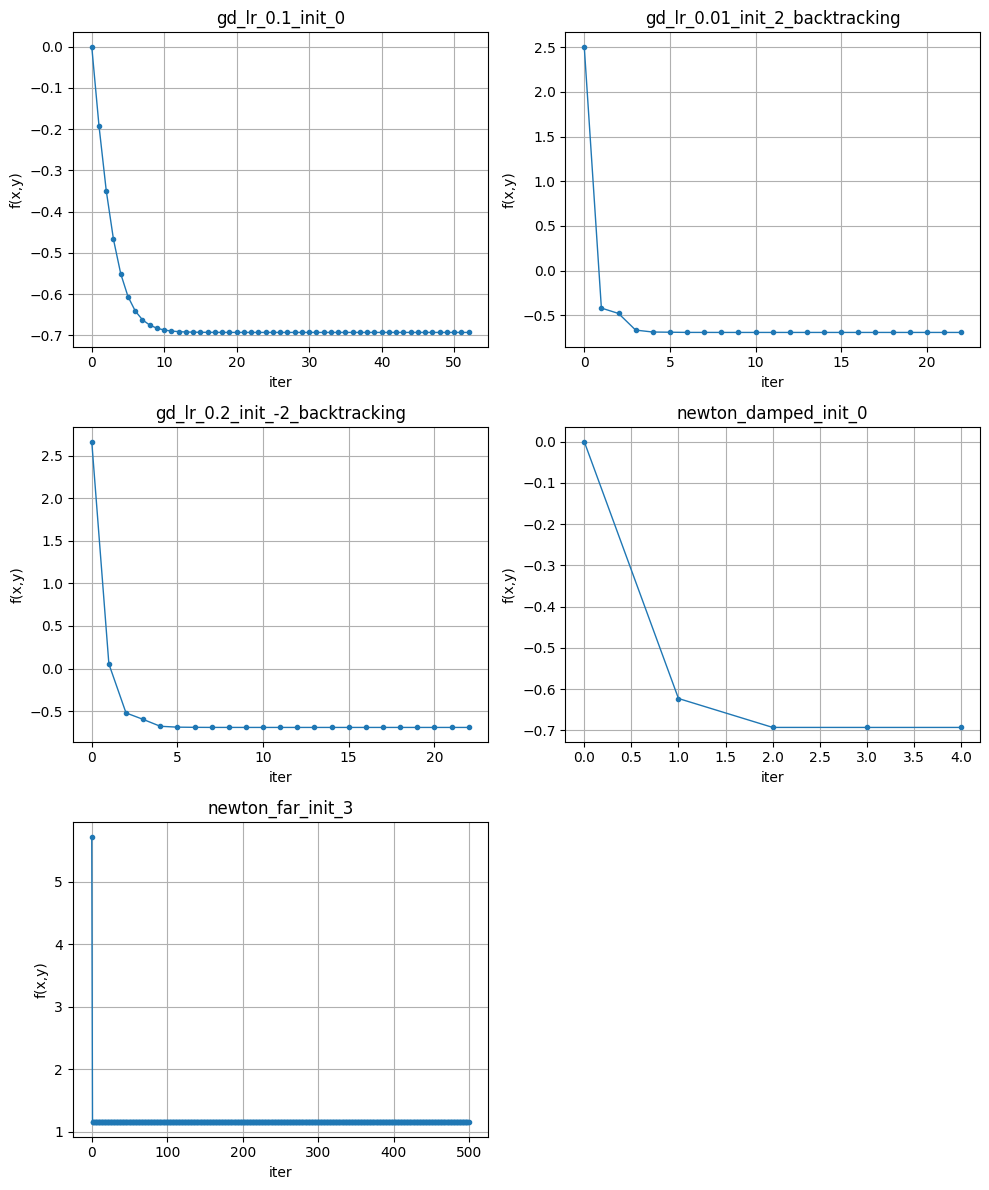

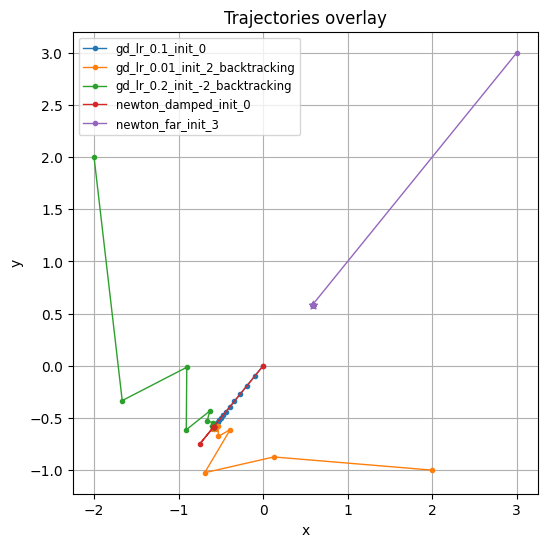

Wrote experiments_summary.csv


In [13]:
#Graficación y análisis de resultados
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

RESULTS_FILE = "experiments_results.json"

def load_results(fname=RESULTS_FILE):
    with open(fname, "r") as fp:
        return json.load(fp)

def summary_table(results):
    rows = []
    for r in results:
        cfg = r["config"]
        res = r["result"]
        rows.append({
            "name": cfg["name"],
            "method": cfg["method"],
            "init": tuple(cfg["init"]),
            "final_x": res["x"][0],
            "final_y": res["x"][1],
            "f_final": res["f"],
            "grad_norm": res["grad_norm"],
            "iters": res["iters"]
        })
    df = pd.DataFrame(rows)
    return df

def plot_objective_vs_iter(res, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    fs = res["history"]["fs"]
    ax.plot(fs, marker='.', linewidth=1)
    ax.set_ylabel("f(x,y)")
    ax.set_xlabel("iter")
    ax.set_title(res["config"]["name"])
    ax.grid(True)
    return ax

def plot_trajectory_2d(res, ax=None):
    xs = np.array(res["history"]["xs"])
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(xs[:,0], xs[:,1], marker='o', linewidth=1)
    ax.scatter(xs[0,0], xs[0,1], marker='s', label='start')
    ax.scatter(xs[-1,0], xs[-1,1], marker='*', label='end')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(res["config"]["name"] + " trajectory")
    ax.legend()
    ax.grid(True)
    return ax

def comparative_plots(results):
    # 1) Summary table
    df = summary_table(results)
    print("=== Summary Table ===")
    print(df.to_string(index=False))
    # 2) Plot objective curves in subplots
    n = len(results)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axs = plt.subplots(rows, cols, figsize=(10, 4*rows))
    axs = axs.flatten()
    for i, r in enumerate(results):
        plot_objective_vs_iter(r, ax=axs[i])
    for j in range(i+1, rows*cols):
        axs[j].axis('off')
    plt.tight_layout()
    plt.show()

    # 3) Plot trajectories overlay (separate by method)
    fig, ax = plt.subplots(figsize=(6,6))
    for r in results:
        xs = np.array(r["history"]["xs"])
        ax.plot(xs[:,0], xs[:,1], marker='.', linewidth=1, label=r["config"]["name"])
        ax.scatter(xs[-1,0], xs[-1,1], marker='*')
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("Trajectories overlay")
    ax.legend(fontsize='small')
    ax.grid(True)
    plt.show()

if __name__ == "__main__":
    results = load_results()
    comparative_plots(results)
    df = summary_table(results)
    # Save comparative table to CSV
    df.to_csv("experiments_summary.csv", index=False)
    print("Wrote experiments_summary.csv")


En los experimentos realizados, se observa una clara diferencia en el comportamiento del gradiente descendente (GD) y del método de Newton con damping al optimizar la función. Según se puede observar en la tabla resumen, los experimentos con GD desde diferentes puntos iniciales (0,0), (2,-1) y (-2,2) convergen todos a punto cercano a (-0.586506,-0.586506) con un valor final de la función aproximado a -0.6926. La norma del gradiente es muy pequeña (∼10**7), lo que indica que se alcanzó un mínimo local estable. Sin embargo, GD requirió 23 a 53 iteraciones para llegar a estos resultados, mostrando un descenso relativamente gradual y sensible al tamaño del paso inicial y al uso de backtracking.

Por su parte, Newton con damping también converge al mismo mínimo cercano al origen cuando se inicia desde (0,0), pero lo logra en solo 5 iteraciones, con una norma del gradiente extremadamente pequeña (∼10**11), reflejando la convergencia cuadrática característica del método y su capacidad de aprovechar la curvatura de la función. Esto evidencia que Newton puede alcanzar el mínimo global de manera mucho más rápida y eficiente que GD cuando se encuentra relativamente cerca del valle parabólico.
Es interesante notar que cuando Newton se inicia desde un punto lejano como (3,3) el método converge a un mínimo diferente alrededor de (0.5847,0.5847) con un valor en la función aproximado a 1.148, alcanza el máximo número de iteraciones permitido (500). Esto resalta que Newton, aunque muy eficiente cerca de un mínimo, encuentra el mínimo más cercano al punto inicial, y el damping evita que diverja en regiones alejadas, pero no garantiza alcanzar el mínimo global desde cualquier posición inicial.

En términos de trayectorias y eficiencia:

El gradiente descendente tiene:
pasos pequeños, descenso gradual, sensible al paso inicial y al backtracking, puede requerir muchas iteraciones, pero encuentra consistentemente un mínimo local cercano al punto inicial.

Y, Newton con damping: 
pasos más precisos y directos, muy pocas iteraciones cerca del mínimo, converge rápidamente y con gran estabilidad, pero el resultado final depende fuertemente del punto inicial, especialmente en regiones donde la función tiene múltiples mínimos.

En resumen, la comparación muestra que ambos métodos son capaces de encontrar mínimos locales, pero Newton es significativamente más rápido y eficiente cuando se encuentra en la vecindad de un mínimo, mientras que GD ofrece un comportamiento más predecible y gradual desde cualquier punto inicial. El mínimo global alcanzado en la mayoría de los experimentos cercanos al origen corresponde aproximadamente a (-0.586506,-0.586506) con un valor final de la función aproximado a -0.6926.


